# Importing

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# to create gif
from pathlib import Path

In [2]:
import os
import os.path
import sys
import inspect
currentdir = "C:\\Users\\Krzysztof\\Documents\\GitHub\\DarkMatterProfiles"
parentdir = os.path.dirname(currentdir)
#take file from same directory
sys.path.insert(0, currentdir)

from Determining_the_duration_of_evolution import createPhoDataModel, T_from_log_bst, para_F, find_rho_s_r_s, mass_variables

from createPlots import onePlotDensityProfile, comparisonTwoDensityProfiles, numeratePlots, differenceDensityProfiles, \
                        comparisonThreeDifferenceProfiles

C:\Users\Krzysztof\Documents\GitHub\DarkMatterProfiles\Determining_the_duration_of_evolution.py:557: RuntimeWarning: invalid value encountered in double_scalars
  return np.tanh(r / 10 ** log_r_core_early(log_bst)) / (r * (1 + r) ** 2)


# Set name of two files

In [3]:
# Which file you want compare
file_name_1 = 'ρsol_M_10._t_10._sigma_1.'
path_file_1 = ''

file_name_2 = 'ρsol_M_10._t_10._sigma_50.'
path_file_2 = ''

In [4]:
"""
Some variables is fixed during the executing the file in mathematica. That fixed variables have shown in the name
of the file, which containing the data. Those variables is:

    init_M: (float): the inital mass of the galaxy. If init_M = 10.1 means that our galaxy have Mass = 10**10.1 M_solar.
                     Unit is [M_solar].
    evolution_time: (float): evolution time of the galaxy. Unit is [Gyr].
    sigma_m: (float): cross section of selected DM (SIDM). Unit is [cm^2/g].

"""
#spliting into parts the first file
split_file_name_1 = file_name_1.split("_")

init_M_file_1 = float(split_file_name_1[2])
evolution_time_file_1 = float(split_file_name_1[4])
sigma_m_file_1 = float(split_file_name_1[6])

print(split_file_name_1)
print('init_M:', init_M_file_1, ', evolution_time:', evolution_time_file_1, ', sigma_m:', sigma_m_file_1)

"------------------------------------------------------------------------------------------------------------------"

#spliting into parts the second file
split_file_name_2 = file_name_2.split("_")

init_M_file_2 = float(split_file_name_2[2])
evolution_time_file_2 = float(split_file_name_2[4])
sigma_m_file_2 = float(split_file_name_2[6])

print(split_file_name_2)
print('init_M:', init_M_file_2, ', evolution_time:', evolution_time_file_2, ', sigma_m:', sigma_m_file_2)

['ρsol', 'M', '10.', 't', '10.', 'sigma', '1.']
init_M: 10.0 , evolution_time: 10.0 , sigma_m: 1.0
['ρsol', 'M', '10.', 't', '10.', 'sigma', '50.']
init_M: 10.0 , evolution_time: 10.0 , sigma_m: 50.0


# Search the path to those files

In [5]:
# searching for all subfolders \data the two file of our interest

for dirpath, dirnames, filenames in os.walk(".\data\data-t-10-Gyr"):
    for filename in [f for f in filenames if f.endswith(".txt")]:
        # find the path
        
        if filename == file_name_1 + ".txt":
            path_file_1 = os.path.join(dirpath, filename)
        
        if filename == file_name_2 + ".txt":
            path_file_2 = os.path.join(dirpath, filename)
            
        # printing all files in subdiretories
        # print(os.path.join(dirpath, filename))
        
        # printing all file names!
        # print(filename)
        
print("path_file_1: ", path_file_1)
print("path_file_2: ", path_file_2)

path_file_1:  .\data\data-t-10-Gyr\rho_M_1x10^10.0\ρsol_M_10._t_10._sigma_1..txt
path_file_2:  .\data\data-t-10-Gyr\rho_M_1x10^10.0\ρsol_M_10._t_10._sigma_50..txt


# Create rho_model

In [6]:
"""
Shortcuts:
    sim: simulation
    mod: model
    f1: file_1
    f2: file_2
"""

# Data coresponding to first file
data_sim_file_1 = pd.read_csv(path_file_1, sep='\t', names=['t', 'r', 'rho'])
data_sim_file_1 = data_sim_file_1.apply(pd.to_numeric, errors = 'coerce').dropna() # dropping the lines with broken r
data_mod_file_1 = createPhoDataModel(data_sim_file_1['r'],
                                     data_sim_file_1['t'],
                                     sigma_m_file_1, init_M_file_1)
# Data coresponding to second file
data_sim_file_2 = pd.read_csv(path_file_2, sep='\t', names=['t', 'r', 'rho'])
data_sim_file_2 = data_sim_file_2.apply(pd.to_numeric, errors = 'coerce').dropna() # dropping the lines with broken r
data_mod_file_2 = createPhoDataModel(data_sim_file_2['r'],
                                     data_sim_file_2['t'],
                                     sigma_m_file_2, init_M_file_2)

# print(data_sim_file_1)
# print(data_sim_file_2)

C:\Users\Krzysztof\AppData\Local\Temp\ipykernel_9072\1402114270.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sim_file_1 = pd.read_csv(path_file_1, sep='\t', names=['t', 'r', 'rho'])
C:\Users\Krzysztof\AppData\Local\Temp\ipykernel_9072\1402114270.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sim_file_2 = pd.read_csv(path_file_2, sep='\t', names=['t', 'r', 'rho'])


In [7]:
#different values of time. In another words number of steps in time
len_t_f1 = 0
while data_sim_file_1['t'][len_t_f1] == data_sim_file_1['t'][0]: len_t_f1 += 1
    
# how many steps on time is in the .txt file
time_steps_f1 =int(len(data_sim_file_1['t']) / len_t_f1)
print('Number of time steps in first file:', time_steps_f1)

"-----------------------------------------------------------------------------------------------"

#different values of time. In another words number of steps in time
len_t_f2 = 0
while data_sim_file_2['t'][len_t_f2] == data_sim_file_2['t'][0]: len_t_f2 += 1
    
# how many steps on time is in the .txt file
time_steps_f2 =int(len(data_sim_file_2['t']) / len_t_f2)
print('Number of time steps in second file:', time_steps_f2)

Number of time steps in first file: 2001
Number of time steps in second file: 2001


# Comparison of density profiles

In [8]:
def DensityProfilesTwoFiles(_sim_time_f1, _sim_radius_f1, _sim_rho_f1,
                            _mod_rho_f1, 
                            _selected_period_f1, _power_mass_f1, _sigma_m_f1,
                            _sim_time_f2, _sim_radius_f2, _sim_rho_f2,
                            _mod_rho_f2,
                            _selected_period_f2, _power_mass_f2, _sigma_m_f2):
    """
    :param _sim_time_f1: (double): list containing the all times of evolution of selected galaxy. This data coming from
                                 the .txt file, which is created in mathematica.
    :param _sim_radius_f1: (double): list containing the all values of radius of selected galaxy. This data coming from
                                   the .txt file, which is created in mathematica.
    :param _sim_rho_f1: (double): the density of DM taking from .txt file.
    :param _mod_rho_f1: (double): the density of dark matter in selected radius and time \rho (r,t). Returning for all
                                 times and all radiuses. This density has been computing according to paper 2205.02957.
    :param _selected_period_f1: (int): the number of selected period, which you want see.
    :return: Nothing. This functions has been intended to compare two density profiles for different files - so for
             various variables fixed in simulation.
    """
    # different values of time. In other words number of steps in time.
    len_t = 0
    while _sim_time_f1[len_t] == _sim_time_f1[0]: len_t += 1

    "--------------------------------------FILE 1---------------------------------------------------------"
    # we want to present the part of whole list in our plot (one period in each plot)
    left_arg = _selected_period_f1 * len_t
    right_arg = (_selected_period_f1 + 1) * len_t
    # data, which occur in our plot
    radius_f1_points = np.log10(_sim_radius_f1[left_arg:right_arg])
    rho_sim_f1_points = np.log10(_sim_rho_f1[left_arg:right_arg])
    rho_mod_f1_points = np.log10(_mod_rho_f1[left_arg:right_arg])
    # time point to get the time in SI - in the title of plot
    time_point_f1 = _sim_time_f1[_selected_period_f1 * len_t + 1]
    
    "--------------------------------------FILE 2---------------------------------------------------------"
    # we want to present the part of whole list in our plot (one period in each plot)
    left_arg = _selected_period_f2 * len_t
    right_arg = (_selected_period_f2 + 1) * len_t
    # data, which occur in our plot
    radius_f2_points = np.log10(_sim_radius_f2[left_arg:right_arg])
    rho_sim_f2_points = np.log10(_sim_rho_f2[left_arg:right_arg])
    rho_mod_f2_points = np.log10(_mod_rho_f2[left_arg:right_arg])
    # time point to get the time in SI - in the title of plot
    time_point_f2 = _sim_time_f2[_selected_period_f2 * len_t + 1]
    

    # Create plot
    fig, ax = plt.subplots(figsize=(7.0, 7.0))
    # data first file
#     ax.plot(radius_f1_points, rho_sim_f1_points, color='blue', label=f'Simulation file 1, time step ={_selected_period_f1}' + "\n" +
#                                         f'mass = 10^{"{:.1f}".format(_power_mass_f1)} [M_sol], sigma_m = {_sigma_m_f1}.')
    ax.plot(radius_f1_points, rho_mod_f1_points, color='blue', linestyle='--', label='Model file 1, time step = ' + str(_selected_period_f1))
    # data second file
#     ax.plot(radius_f2_points, rho_sim_f2_points, color='orange', label=f'Simulation file 2, time step ={_selected_period_f2}' + "\n" +
#                                         f'mass = 10^{"{:.1f}".format(_power_mass_f2)} [M_sol], sigma_m = {_sigma_m_f2}.')
    ax.plot(radius_f2_points, rho_mod_f2_points, color='orange', linestyle='--', label='Model file 2, time step = ' + str(_selected_period_f2))
    # Settings
    plt.ylim(-3.0, 1.0)
    plt.xlim(-1.5,1)
    plt.ylabel(r'$\log\rho(r)$', fontsize=18)
    plt.xlabel(r'$\log(r)$', fontsize=18)
    plt.title(f'Density profile on: {"%10.2e" % (10 ** time_point_f1)} Gyr (file 1).' + '\n' +
              f'Density profile on: {"%10.2e" % (10 ** time_point_f2)} Gyr (file 2).', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend()
    plt.show()

In [19]:
def DensityProfilesTwoFiles_sim(_sim_time_f1, _sim_radius_f1, _sim_rho_f1,
                            _mod_rho_f1, 
                            _selected_period_f1, _power_mass_f1, _sigma_m_f1,
                            _sim_time_f2, _sim_radius_f2, _sim_rho_f2,
                            _mod_rho_f2,
                            _selected_period_f2, _power_mass_f2, _sigma_m_f2):
    """
    :param _sim_time_f1: (double): list containing the all times of evolution of selected galaxy. This data coming from
                                 the .txt file, which is created in mathematica.
    :param _sim_radius_f1: (double): list containing the all values of radius of selected galaxy. This data coming from
                                   the .txt file, which is created in mathematica.
    :param _sim_rho_f1: (double): the density of DM taking from .txt file.
    :param _mod_rho_f1: (double): the density of dark matter in selected radius and time \rho (r,t). Returning for all
                                 times and all radiuses. This density has been computing according to paper 2205.02957.
    :param _selected_period_f1: (int): the number of selected period, which you want see.
    :return: Nothing. This functions has been intended to compare two density profiles for different files - so for
             various variables fixed in simulation.
    """
    # different values of time. In other words number of steps in time.
    len_t = 0
    while _sim_time_f1[len_t] == _sim_time_f1[0]: len_t += 1

    "--------------------------------------FILE 1---------------------------------------------------------"
    # we want to present the part of whole list in our plot (one period in each plot)
    left_arg = _selected_period_f1 * len_t
    right_arg = (_selected_period_f1 + 1) * len_t
    # data, which occur in our plot
    radius_f1_points = np.log10(_sim_radius_f1[left_arg:right_arg])
    rho_sim_f1_points = np.log10(_sim_rho_f1[left_arg:right_arg])
    rho_mod_f1_points = np.log10(_mod_rho_f1[left_arg:right_arg])
    # time point to get the time in SI - in the title of plot
    time_point_f1 = _sim_time_f1[_selected_period_f1 * len_t + 1]
    
    "--------------------------------------FILE 2---------------------------------------------------------"
    # we want to present the part of whole list in our plot (one period in each plot)
    left_arg = _selected_period_f2 * len_t
    right_arg = (_selected_period_f2 + 1) * len_t
    # data, which occur in our plot
    radius_f2_points = np.log10(_sim_radius_f2[left_arg:right_arg])
    rho_sim_f2_points = np.log10(_sim_rho_f2[left_arg:right_arg])
    rho_mod_f2_points = np.log10(_mod_rho_f2[left_arg:right_arg])
    # time point to get the time in SI - in the title of plot
    time_point_f2 = _sim_time_f2[_selected_period_f2 * len_t + 1]
    

    # Create plot
    fig, ax = plt.subplots(figsize=(7.0, 7.0))
    # data first file
    ax.plot(radius_f1_points, rho_sim_f1_points, color='blue', label=f'Simulation file 1, time step ={_selected_period_f1}' + "\n" +
                                        f'mass = 10^{"{:.1f}".format(_power_mass_f1)} [M_sol], sigma_m = {_sigma_m_f1}.')
    ax.plot(radius_f1_points, rho_mod_f1_points, color='blue', linestyle='--', label='Model file 1, time step = ' + str(_selected_period_f1))
    # data second file
#     ax.plot(radius_f2_points, rho_sim_f2_points, color='orange', label=f'Simulation file 2, time step ={_selected_period_f2}' + "\n" +
#                                         f'mass = 10^{"{:.1f}".format(_power_mass_f2)} [M_sol], sigma_m = {_sigma_m_f2}.')
#     ax.plot(radius_f2_points, rho_mod_f2_points, color='orange', linestyle='--', label='Model file 2, time step = ' + str(_selected_period_f2))
    # Settings
    plt.ylim(-3.0, 1.0)
    plt.xlim(-1.5,1)
    plt.ylabel(r'$\log\rho(r)$', fontsize=18)
    plt.xlabel(r'$\log(r)$', fontsize=18)
#     plt.title(f'Density profile on: {"%10.2e" % (10 ** time_point_f1)} Gyr (file 1).' + '\n' +
#               f'Density profile on: {"%10.2e" % (10 ** time_point_f2)} Gyr (file 2).', fontsize=18)
    plt.title(f'Density profile on: {"%10.2e" % (10 ** time_point_f1)} Gyr (file 1).' + '\n' +
              f'Density profile on: {"%10.2e" % (10 ** time_point_f2)} Gyr (file 2).', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend()
    plt.show()

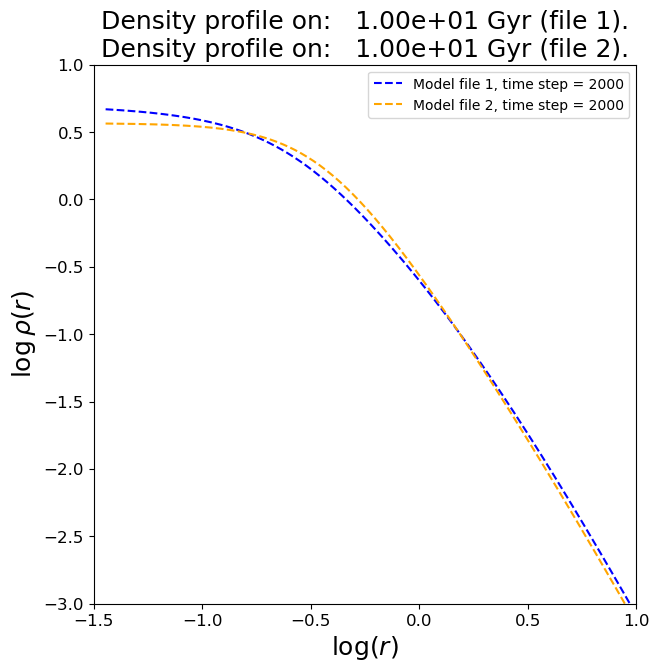

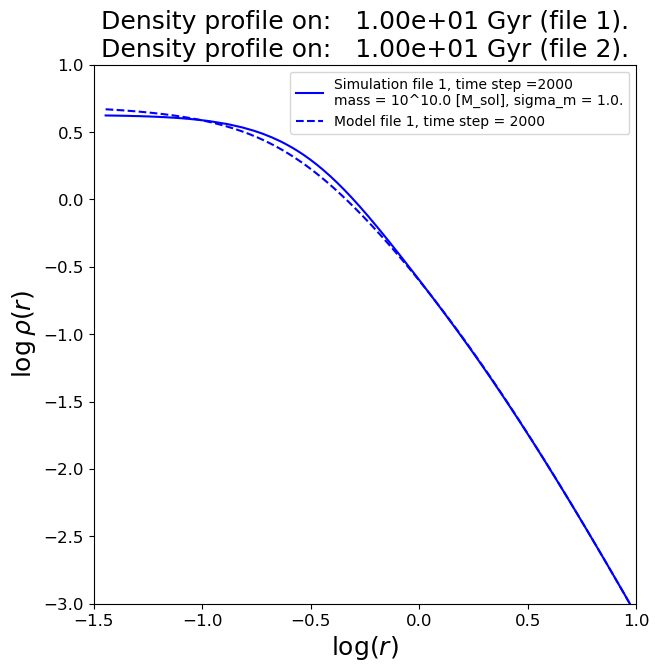

In [20]:
"""
comparison at 10 Gyr
"""
last_step_f1 = time_steps_f1 - 1
last_step_f2 = time_steps_f2 - 1

DensityProfilesTwoFiles(data_sim_file_1['t'], data_sim_file_1['r'], data_sim_file_1['rho'],
                        data_mod_file_1,
                        last_step_f1, init_M_file_1, sigma_m_file_1,
                        data_sim_file_2['t'], data_sim_file_2['r'], data_sim_file_2['rho'],
                        data_mod_file_2,
                        last_step_f2, init_M_file_2, sigma_m_file_2)

DensityProfilesTwoFiles_sim(data_sim_file_1['t'], data_sim_file_1['r'], data_sim_file_1['rho'],
                        data_mod_file_1,
                        last_step_f1, init_M_file_1, sigma_m_file_1,
                        data_sim_file_2['t'], data_sim_file_2['r'], data_sim_file_2['rho'],
                        data_mod_file_2,
                        last_step_f2, init_M_file_2, sigma_m_file_2)

period first file: 1670
period second file: 1980


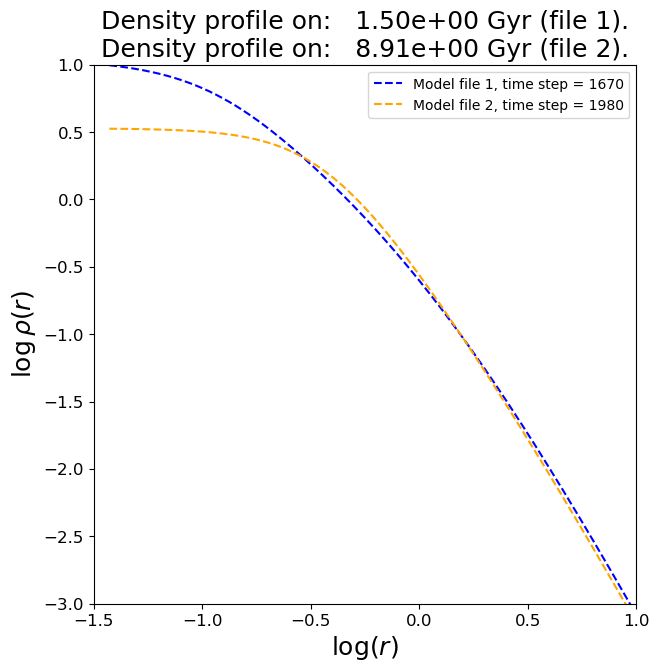

In [11]:
"""
Now you can compare two arbitraly files for arbitrary times! (they can be different)
"""
# only those changing!
time_f1_Gyr = 1.5 # [Gyr]
time_f2_Gyr = 8.9 # [Gyr]

"-----------------------------------------------------------------------------------------------------"

selected_f1_T = np.log10(time_f1_Gyr) # log10(Gyr)
selected_f2_T = np.log10(time_f2_Gyr) # log10(Gyr)

# closet time step to time of file 1
closest_time_f1 = data_sim_file_1.iloc[(data_sim_file_1['t'] - selected_f1_T).abs().argsort()[:1]]
closest_time_f1_index = (closest_time_f1['t'].index)[0] # how to get index
closest_time_f1_step = int(closest_time_f1_index / len_t_f1)

# closet time step to time of file 1
closest_time_f2 = data_sim_file_2.iloc[(data_sim_file_2['t'] - selected_f2_T).abs().argsort()[:1]]
closest_time_f2_index = (closest_time_f2['t'].index)[0] # how to get index
closest_time_f2_step = int(closest_time_f2_index / len_t_f2)

print("period first file:", closest_time_f1_step)
print("period second file:", closest_time_f2_step)

# plotting
DensityProfilesTwoFiles(data_sim_file_1['t'], data_sim_file_1['r'], data_sim_file_1['rho'],
                        data_mod_file_1,
                        closest_time_f1_step, init_M_file_1, sigma_m_file_1,
                        data_sim_file_2['t'], data_sim_file_2['r'], data_sim_file_2['rho'],
                        data_mod_file_2,
                        closest_time_f2_step, init_M_file_2, sigma_m_file_2)